# FitSmart - AI Food Recognition Model
**Tim CC26-PSU394** - 

Pipeline:
1. Setup & konfigurasi
2. Load dataset + augmentasi
3. Bangun model (TF Functional API + Custom Components)
4. Training + Custom Callback
5. Evaluasi performa
6. Export model (.keras & SavedModel)
7. Inference sederhana

In [1]:
!pip install -q tensorflow gdown Pillow scikit-learn seaborn

In [1]:
import os, json, zipfile, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from pathlib import Path
import gdown

warnings.filterwarnings('ignore')
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.21.0
GPU available      : []


In [2]:
# Konfigurasi
BASE_DIR    = '/content/fitsmart'
IMAGES_DIR  = f'{BASE_DIR}/images'
OUTPUT_DIR  = f'{BASE_DIR}/output'
MODEL_DIR   = f'{BASE_DIR}/model'

URL_IMAGES_ZIP    = 'https://drive.google.com/uc?id=1fTIbuFDclnZobr0_EQG9M6elgD-pJyh4'
URL_NUTRITION_CSV = 'https://drive.google.com/uc?export=download&id=1KSpvR7QK7bOBGHK0JPe4Dlpbh3unqnjb'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 1e-3
SEED       = 42

for d in [BASE_DIR, IMAGES_DIR, OUTPUT_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
print("Konfigurasi berhasil")

Konfigurasi berhasil


## 1. Download & Load Dataset

In [3]:
ZIP_PATH = f'{BASE_DIR}/images.zip'

if not any(Path(IMAGES_DIR).iterdir()):
    print("Downloading dataset gambar...")
    gdown.download(URL_IMAGES_ZIP, ZIP_PATH, quiet=False)
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(IMAGES_DIR)
    os.remove(ZIP_PATH)

    # Rapikan folder container
    extracted = [d for d in Path(IMAGES_DIR).iterdir() if d.is_dir()]
    if len(extracted) == 1 and len(list(extracted[0].iterdir())) > 1:
        inner = extracted[0]
        for item in inner.iterdir():
            shutil.move(str(item), IMAGES_DIR)
        inner.rmdir()
else:
    print("Dataset sudah tersedia, skip download.")

n_classes = len([d for d in Path(IMAGES_DIR).iterdir() if d.is_dir()])
print(f"Total kelas ditemukan: {n_classes}")

Dataset sudah tersedia, skip download.
Total kelas ditemukan: 24


In [4]:
# Load class mapping dari output EDA (Dataset_FitSmart.ipynb)
CLASS_MAP_PATH = f'{OUTPUT_DIR}/class_mapping.json'

# Fallback: generate dari folder gambar
if not os.path.exists(CLASS_MAP_PATH):
    print("class_mapping.json tidak ditemukan, generate dari folder...")
    labels = sorted([d.name for d in Path(IMAGES_DIR).iterdir() if d.is_dir()])
    mapping_fb = {
        "n_classes": len(labels),
        "cls2idx":   {l: i for i, l in enumerate(labels)},
        "idx2cls":   {str(i): l for i, l in enumerate(labels)},
        "nutrition": {}
    }
    with open(CLASS_MAP_PATH, 'w') as f:
        json.dump(mapping_fb, f, indent=2, ensure_ascii=False)

with open(CLASS_MAP_PATH) as f:
    MAPPING = json.load(f)

N_CLASSES = MAPPING["n_classes"]
IDX2CLS   = MAPPING["idx2cls"]
CLS2IDX   = MAPPING["cls2idx"]
NUTRITION = MAPPING.get("nutrition", {})

print(f"N_CLASSES : {N_CLASSES}")
print(f"Contoh label: {list(CLS2IDX.keys())[:5]}")

N_CLASSES : 24
Contoh label: ['Ayam Goreng', 'Ikan Goreng', 'Mie Goreng', 'alpukat', 'apel']


## 2. tf.data Pipeline (Augmentasi + Split 80/20)

In [5]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    IMAGES_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    shuffle=True,
    image_size=(224, 224),
    batch_size=32
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    IMAGES_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    shuffle=True,
    image_size=(224, 224),
    batch_size=32
)

CLASS_NAMES = train_ds_raw.class_names
print(f"Kelas ({len(CLASS_NAMES)}): {CLASS_NAMES[:5]}...")
print(f"Train batches : {len(train_ds_raw)}")
print(f"Val   batches : {len(val_ds_raw)}")

Found 4231 files belonging to 24 classes.
Using 3385 files for training.
Found 4231 files belonging to 24 classes.
Using 846 files for validation.
Kelas (24): ['Ayam Goreng', 'Ikan Goreng', 'Mie Goreng', 'alpukat', 'apel']...
Train batches : 106
Val   batches : 27


In [6]:
class_names = val_ds_raw.class_names

In [7]:
class_names = val_ds_raw.class_names

from collections import Counter

y_true = []

for images, labels in val_ds_raw:
    y_true.extend(labels.numpy().astype(int).flatten().tolist())

counter = Counter(y_true)

for class_index, total in counter.items():
    print(class_names[int(class_index)], total)

soto 69
bebek_betutu 46
sate 75
ubi 15
Ayam Goreng 72
alpukat 14
bakso 63
mangga 4
rendang 57
Ikan Goreng 25
kentang 13
pempek 49
bayam 26
tomat 18
nasi_goreng 61
rawon 58
apel 8
semangka 18
gudeg 49
gado_gado 48
pisang 8
Mie Goreng 24
wortel 18
jeruk 8


## clas weight

In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = []

for images, labels in train_ds_raw:
    y_train.extend(labels.numpy().astype(int).flatten().tolist())

y_train = np.array(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    i: weight for i, weight in enumerate(class_weights)
}

print(class_weight_dict)

{0: np.float64(0.430005081300813), 1: np.float64(1.4104166666666667), 2: np.float64(1.4846491228070176), 3: np.float64(3.066123188405797), 4: np.float64(4.407552083333333), 5: np.float64(0.5596891534391535), 6: np.float64(1.9865023474178405), 7: np.float64(0.7345920138888888), 8: np.float64(0.6560077519379846), 9: np.float64(0.860010162601626), 10: np.float64(4.407552083333333), 11: np.float64(2.2037760416666665), 12: np.float64(3.917824074074074), 13: np.float64(0.462431693989071), 14: np.float64(0.595112517580872), 15: np.float64(4.407552083333333), 16: np.float64(0.7968455743879472), 17: np.float64(0.7835648148148148), 18: np.float64(0.5037202380952381), 19: np.float64(2.1369949494949494), 20: np.float64(0.48803344867358706), 21: np.float64(1.9059684684684686), 22: np.float64(2.611882716049383), 23: np.float64(2.2037760416666665)}


In [9]:
# Augmentasi (hanya saat training)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(image, label):
    image = data_augmentation(image, training=True)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def preprocess_val(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds_raw.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.map(preprocess_val,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Pipeline data siap (augmented + prefetched)")

Pipeline data siap (augmented + prefetched)


## 3. Komponen Kustom (Main Quest Checklist)

Tiga komponen kustom diimplementasikan sesuai checklist MVP:

| No | Komponen | Nama |
|----|----------|------|
| 1 | **Custom Layer** | `ChannelAttention` - Squeeze-and-Excitation block |
| 2 | **Custom Loss** | `FocalLoss` - menangani class imbalance |
| 3 | **Custom Callback** | `PerformanceGuardCallback` - monitoring & auto-stop |

In [10]:
# Custom Layer: Channel Attention (SE Block)
class ChannelAttention(layers.Layer):
    """Squeeze-and-Excitation block: memperkuat fitur penting per channel."""

    def __init__(self, reduction_ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        reduced  = max(1, channels // self.reduction_ratio)
        self.gap     = layers.GlobalAveragePooling2D()
        self.fc1     = layers.Dense(reduced, activation="relu")
        self.fc2     = layers.Dense(channels, activation="sigmoid")
        self.reshape = layers.Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, inputs):
        x = self.gap(inputs)     # (B, C)
        x = self.fc1(x)          # (B, C/r)
        x = self.fc2(x)          # (B, C)
        x = self.reshape(x)      # (B, 1, 1, C)
        return inputs * x        # channel-wise reweighting

    def get_config(self):
        config = super().get_config()
        config.update({"reduction_ratio": self.reduction_ratio})
        return config

print("ChannelAttention (Custom Layer) didefinisikan")

ChannelAttention (Custom Layer) didefinisikan


In [12]:
# Custom Loss: Focal Loss (Updated for Deserialization)
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss untuk class-imbalanced dataset.
    """

    # FIX: Added **kwargs to catch the 'reduction' parameter Keras passes during loading
    def __init__(self, gamma=2.0, alpha=0.25, name="focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_one_hot = tf.cast(y_true, tf.float32)
        y_pred    = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_ent = -y_one_hot * tf.math.log(y_pred)
        p_t       = tf.reduce_sum(y_one_hot * y_pred, axis=-1)
        focal_w   = self.alpha * tf.pow(1.0 - p_t, self.gamma)

        loss = focal_w * tf.reduce_sum(cross_ent, axis=-1)
        return tf.reduce_mean(loss)

    def get_config(self):
        config = super().get_config()
        config.update({"gamma": self.gamma, "alpha": self.alpha})
        return config

print("FocalLoss (Custom Loss) didefinisikan ulang")

FocalLoss (Custom Loss) didefinisikan ulang


In [13]:
# Custom Callback: PerformanceGuardCallback
class PerformanceGuardCallback(callbacks.Callback):
    """
    Custom callback yang:
    - Mencetak progress bar akurasi tiap epoch
    - Auto-stop jika val_accuracy >= target selama N epoch berturut
    - Melaporkan status MVP (acc >= 85%) di akhir training
    """

    def __init__(self, target_acc=0.90, patience=4, log_every=1):
        super().__init__()
        self.target_acc  = target_acc
        self.patience    = patience
        self.log_every   = log_every
        self.wait        = 0
        self.best_acc    = 0.0

    def on_epoch_end(self, epoch, logs=None):
        logs    = logs or {}
        val_acc = logs.get("val_accuracy", 0)
        tr_acc  = logs.get("accuracy", 0)

        if (epoch + 1) % self.log_every == 0:
            filled = int(val_acc * 20)
            bar    = "#" * filled + "." * (20 - filled)
            print(f"  [Ep {epoch+1:03d}] train={tr_acc:.4f} | val={val_acc:.4f} |{bar}|")

        if val_acc >= self.target_acc:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"\n[INFO] Target {self.target_acc:.0%} tercapai {self.patience}x berturut. Training dihentikan.")
                self.model.stop_training = True
        else:
            self.wait = 0

        self.best_acc = max(self.best_acc, val_acc)

    def on_train_end(self, logs=None):
        status = "LULUS" if self.best_acc >= 0.85 else "BELUM LULUS"
        print(f"\n{'='*52}")
        print(f"  TRAINING SELESAI")
        print(f"  Best val_accuracy : {self.best_acc:.4f}  ({self.best_acc*100:.2f}%)")
        print(f"  Status MVP (>=85%): {status}")
        print(f"{'='*52}")

print("PerformanceGuardCallback (Custom Callback) didefinisikan")

PerformanceGuardCallback (Custom Callback) didefinisikan


## 4. Bangun Model - TensorFlow Functional API

In [14]:
def build_fitsmart_model(n_classes, img_size=(224, 224)):
    """
    Arsitektur FitSmart menggunakan Functional API:
    - Backbone  : MobileNetV2 pretrained ImageNet
                  (fine-tune 30 layer terakhir)
    - Attention : ChannelAttention (Custom Layer)
    - Head      : GAP -> Dense(256, relu) -> BN -> Dropout(0.4) -> Softmax
    """
    inputs = keras.Input(shape=(*img_size, 3), name="image_input")

    # Backbone
    backbone = keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
    )
    backbone.trainable = True
    for layer in backbone.layers[:-30]:
        layer.trainable = False

    x = backbone.output                        # (B, 7, 7, 1280)

    # Custom Layer: SE Attention
    x = ChannelAttention(reduction_ratio=16, name="se_attention")(x)

    # Classification Head
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(
            256, activation="relu",
            kernel_regularizer=keras.regularizers.l2(1e-4),
            name="dense_256")(x)
    x = layers.BatchNormalization(name="bn")(x)
    x = layers.Dropout(0.4, name="dropout")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="predictions")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="FitSmart_v1")


model = build_fitsmart_model(N_CLASSES)
model.summary(show_trainable=True)

Model: "FitSmart_v1"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ image_input       │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1 (Conv2D)    │ (None, 112,     │       864 │ image_input[0… │   N   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ bn_Conv1          │ (None, 112,     │       128 │ Conv1[0][0]    │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ Conv1_relu (ReLU) │ (None, 112,     │         0 │ bn_Conv1[0][0] │   -   │
│                   │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       288 │ Conv1_relu[0]… │   N   │
│ (DepthwiseConv2D) │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │       128 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 112,     │         0 │ expanded_conv… │   -   │
│ (ReLU)            │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │       512 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 112,     │        64 │ expanded_conv… │   N   │
│ (BatchNormalizat… │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand    │ (None, 112,     │     1,536 │ expanded_conv… │   N   │
│ (Conv2D)          │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_BN │ (None, 112,     │       384 │ block_1_expan… │   N   │
│ (BatchNormalizat… │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_r… │ (None, 112,     │         0 │ block_1_expan… │   -   │
│ (ReLU)            │ 112, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_pad       │ (None, 113,     │         0 │ block_1_expan… │   -   │
│ (ZeroPadding2D)   │ 113, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwise │ (None, 56, 56,  │       864 │ block_1_pad[0… │   N   │
│ (DepthwiseConv2D) │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │       384 │ block_1_depth… │   N   │
│ (BatchNormalizat… │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_depthwis… │ (None, 56, 56,  │         0 │ block_1_depth… │   -   │
│ (ReLU)            │ 96)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_project   │ (None, 56, 56,  │     2,304 │ block_1_depth… │   N 

 Total params: 2,799,272 (10.68 MB)

 Trainable params: 2,067,176 (7.89 MB)

 Non-trainable params: 732,096 (2.79 MB)

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(
            k=3,
            name="top_3_accuracy"
        )
    ],
)

trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f"Model dikompilasi dengan FocalLoss + Adam")
print(f"Parameter trainable : {trainable:,}")

Model dikompilasi dengan FocalLoss + Adam
Parameter trainable : 2,067,176


## 5. Training

In [16]:
# Callbacks
cb_perf = PerformanceGuardCallback(target_acc=0.92, patience=4)  # Custom Callback

cb_rlr = callbacks.ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.5, patience=4,
    min_lr=1e-6, verbose=0)                          # FIX: min_lr bukan min_1r

cb_ckpt = callbacks.ModelCheckpoint(                 # FIX: ModelCheckpoint bukan Mode1Checkpoint
    filepath=f'{MODEL_DIR}/best_checkpoint.keras',   # FIX: hapus spasi setelah f'
    monitor="val_accuracy", save_best_only=True, verbose=0)

cb_es = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=8,
    restore_best_weights=True, verbose=1)


In [17]:
# List callbacks
callback_list = [
    cb_perf,
    cb_rlr,
    cb_ckpt,
    cb_es
]


In [18]:
# Training
print("Memulai training FitSmart Model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callback_list,
    class_weight=class_weight_dict
)

Memulai training FitSmart Model...
Epoch 1/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.3849 - loss: 2.4713 - top_3_accuracy: 0.5786  [Ep 001] train=0.5022 | val=0.4362 |########............|
106/106 ━━━━━━━━━━━━━━━━━━━━ 87s 694ms/step - accuracy: 0.5022 - loss: 1.9138 - top_3_accuracy: 0.7211 - val_accuracy: 0.4362 - val_loss: 2.4968 - val_top_3_accuracy: 0.6844 - learning_rate: 0.0010
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.6772 - loss: 0.9829 - top_3_accuracy: 0.8948  [Ep 002] train=0.7081 | val=0.6407 |############........|
106/106 ━━━━━━━━━━━━━━━━━━━━ 68s 638ms/step - accuracy: 0.7081 - loss: 0.9333 - top_3_accuracy: 0.9004 - val_accuracy: 0.6407 - val_loss: 1.7082 - val_top_3_accuracy: 0.8534 - learning_rate: 0.0010
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.7593 - loss: 0.7551 - top_3_accuracy: 0.9313  [Ep 003] train=0.7669 | val=0.4515 |#########...........|
106/106 ━━━━━━━━━━━━━━━━━━━━ 81s 759ms/step - accurac

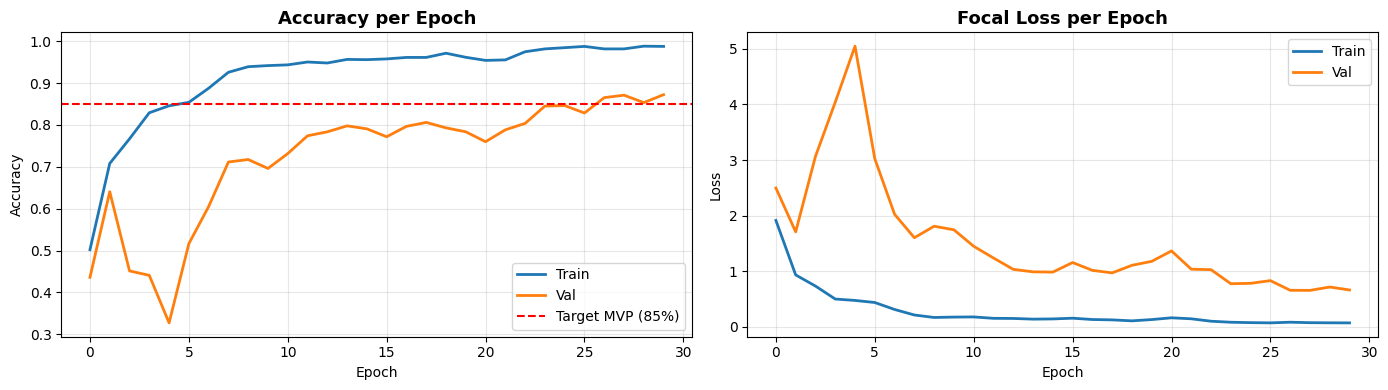

Plot tersimpan: training_history.png


In [19]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2)
axes[0].axhline(0.85, color='red', linestyle='--', label='Target MVP (85%)')
axes[0].set_title('Accuracy per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2)
axes[1].set_title('Focal Loss per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_history.png', dpi=120)
plt.show()
print("Plot tersimpan: training_history.png")

## 6. Evaluasi Performa

              precision    recall  f1-score   support

 Ayam Goreng       0.86      0.96      0.91        72
 Ikan Goreng       0.96      0.88      0.92        25
  Mie Goreng       0.61      0.96      0.74        24
     alpukat       0.93      1.00      0.97        14
        apel       1.00      0.88      0.93         8
       bakso       0.85      0.81      0.83        63
       bayam       0.96      1.00      0.98        26
bebek_betutu       0.97      0.70      0.81        46
   gado_gado       0.68      0.96      0.79        48
       gudeg       0.91      0.84      0.87        49
       jeruk       1.00      1.00      1.00         8
     kentang       0.79      0.85      0.81        13
      mangga       0.67      0.50      0.57         4
 nasi_goreng       0.93      0.85      0.89        61
      pempek       0.85      0.80      0.82        49
      pisang       1.00      1.00      1.00         8
       rawon       0.89      0.88      0.89        58
     rendang       0.94    

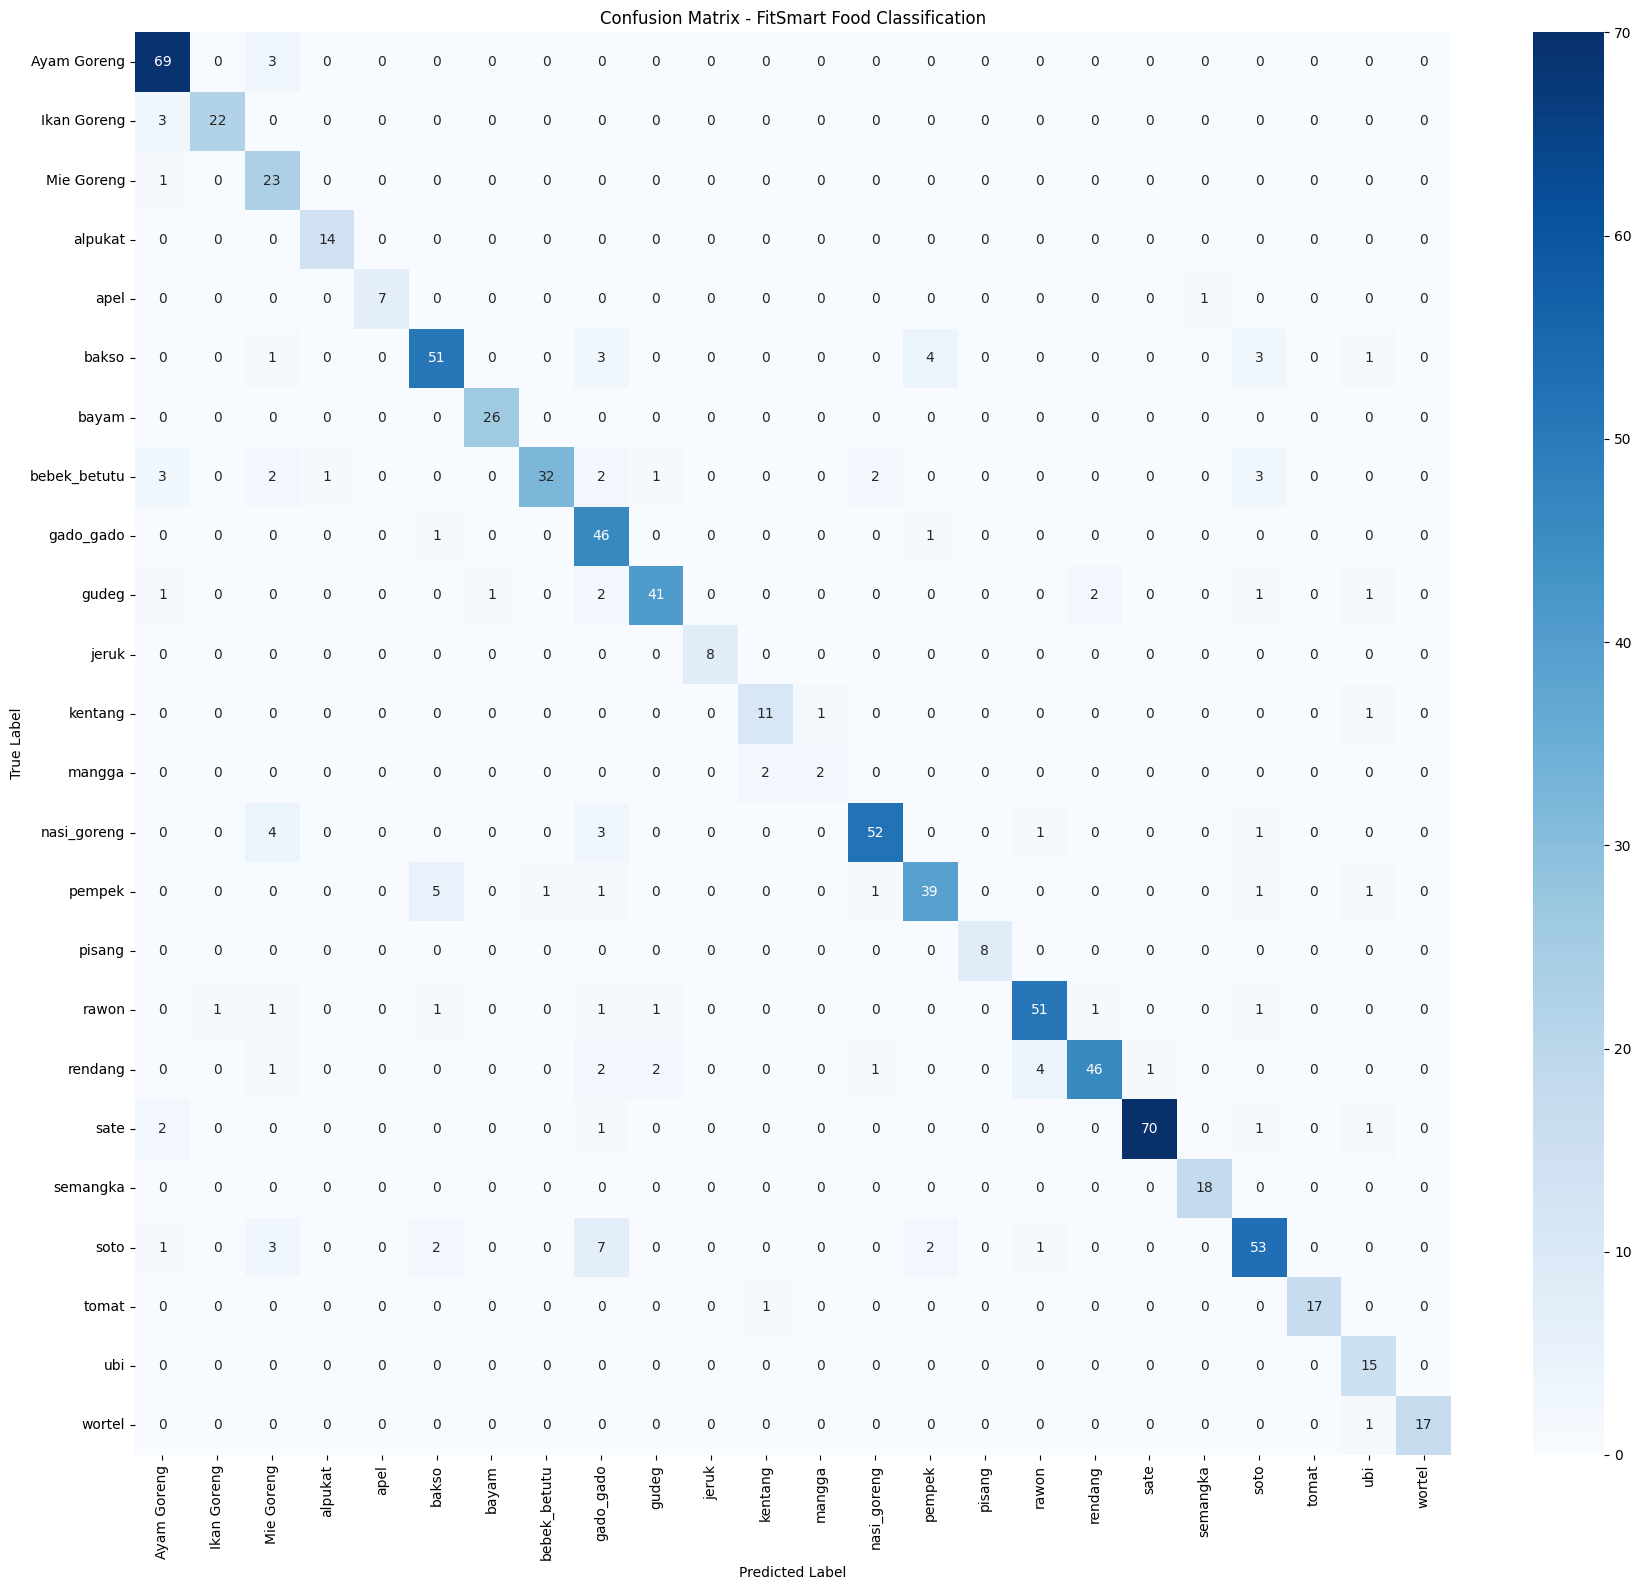

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

class_names = val_ds_raw.class_names

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().astype(int).flatten().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - FitSmart Food Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
print(history.history.keys())
print("Train accuracy terakhir:", history.history["accuracy"][-1])
print("Val accuracy terakhir:", history.history["val_accuracy"][-1])

dict_keys(['accuracy', 'loss', 'top_3_accuracy', 'val_accuracy', 'val_loss', 'val_top_3_accuracy', 'learning_rate'])
Train accuracy terakhir: 0.987592339515686
Val accuracy terakhir: 0.8723404407501221


## 7. Simpan & Export Model (Format Produksi)

In [22]:
val_loss, val_acc, val_mae = model.evaluate(val_ds, verbose=0)

In [32]:
import os
import json
# Folder penyimpanan
MODEL_DIR = r'D:\CodingCamp\CAPSTONE\model'

os.makedirs(MODEL_DIR, exist_ok=True)
# 7a. Format .keras
KERAS_PATH = os.path.join(
    MODEL_DIR,
    'fitsmart_model.keras'
)

model.save(KERAS_PATH)

print(f".keras tersimpan      : {KERAS_PATH}")
# 7b. SavedModel
SAVEDMODEL_PATH = os.path.join(
    MODEL_DIR,
    'fitsmart_savedmodel'
)

model.export(SAVEDMODEL_PATH)

print(f"SavedModel tersimpan  : {SAVEDMODEL_PATH}")
# 7c. class_mapping.json
mapping_out = {
    "n_classes":   N_CLASSES,
    "class_names": CLASS_NAMES,
    "cls2idx":     {c: i for i, c in enumerate(CLASS_NAMES)},
    "idx2cls":     {str(i): c for i, c in enumerate(CLASS_NAMES)},
    "nutrition":   NUTRITION,
    "img_size":    list(IMG_SIZE),
}

mapping_path = os.path.join(
    MODEL_DIR,
    'class_mapping.json'
)

with open(mapping_path, 'w', encoding='utf-8') as f:
    json.dump(
        mapping_out,
        f,
        indent=2,
        ensure_ascii=False
    )
# 7d. eval_metrics.json
metrics_out = {
    "val_accuracy":   round(float(val_acc), 6),
    "val_mae":        round(float(val_mae), 6),
    "val_loss":       round(float(val_loss), 6),
    "mvp_acc_pass":   bool(val_acc >= 0.85),
    "mvp_mae_pass":   bool(val_mae <= 0.02),
    "epochs_trained": EPOCHS if 'history' not in locals()
                       else len(history.history['accuracy']),
    "n_classes":      N_CLASSES,
    "architecture":   "MobileNetV2 + ChannelAttention (SE) + FocalLoss",
}

metrics_path = os.path.join(
    MODEL_DIR,
    'eval_metrics.json'
)

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(
        metrics_out,
        f,
        indent=2
    )
# Ringkasan
print("\nFile model tersimpan di:")
print(MODEL_DIR)

for fname in [
    'fitsmart_model.keras',
    'fitsmart_savedmodel/',
    'class_mapping.json',
    'eval_metrics.json'
]:
    print(f"   {fname}")

.keras tersimpan      : D:\CodingCamp\CAPSTONE\model\fitsmart_model.keras
INFO:tensorflow:Assets written to: D:\CodingCamp\CAPSTONE\model\fitsmart_savedmodel\assets


INFO:tensorflow:Assets written to: D:\CodingCamp\CAPSTONE\model\fitsmart_savedmodel\assets


Saved artifact at 'D:\CodingCamp\CAPSTONE\model\fitsmart_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image_input')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  2016099768976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2016099769936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2016099768016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2016099771280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2016099771472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2016099770896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2016099772816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2016099769744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2016099771088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2016099772624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  20

In [33]:
# Verifikasi load ulang model
loaded_model = keras.models.load_model(
    KERAS_PATH,
    custom_objects={
        "ChannelAttention": ChannelAttention,
        "FocalLoss":        FocalLoss,
    }
)

dummy = tf.zeros((1, *IMG_SIZE, 3))
out   = loaded_model(dummy, training=False)
print(f"Model berhasil dimuat ulang dari {KERAS_PATH}")
print(f"Output shape : {out.shape}")
print(f"Sum probs    : {float(tf.reduce_sum(out)):.4f}  (harus mendekati 1.0)")

Model berhasil dimuat ulang dari D:\CodingCamp\CAPSTONE\model\fitsmart_model.keras
Output shape : (1, 24)
Sum probs    : 1.0000  (harus mendekati 1.0)


## 8. Kode Inference Sederhana (Siap Produksi)

In [34]:
# ============================================================
# MODUL INFERENCE - dapat diimport langsung dari backend
# (Flask / FastAPI / Node.js via subprocess)
# ============================================================

def load_fitsmart_model(model_path: str, mapping_path: str):
    """Load model & class mapping sekali saat startup server."""
    with open(mapping_path) as f:
        mapping = json.load(f)
    mdl = keras.models.load_model(
        model_path,
        custom_objects={"ChannelAttention": ChannelAttention, "FocalLoss": FocalLoss}
    )
    return mdl, mapping


def preprocess_image(image_path: str, img_size=(224, 224)):
    """Preprocess satu gambar dari path menjadi tensor siap predict."""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return tf.expand_dims(img, axis=0)          # (1, H, W, 3)


def predict_food(model, mapping: dict, image_path: str, top_k: int = 3) -> dict:
    """
    Prediksi kelas makanan dari path gambar.

    Args:
        model      : model yang sudah dimuat
        mapping    : dict class mapping (dari class_mapping.json)
        image_path : path ke file gambar
        top_k      : jumlah prediksi teratas yang dikembalikan

    Returns:
        dict dengan kunci:
            - predicted_class : str, label prediksi teratas
            - confidence      : float, nilai kepercayaan (0-1)
            - top_predictions : list of {label, confidence, nutrition}
    """
    img      = preprocess_image(image_path, tuple(mapping["img_size"]))
    probs    = model(img, training=False).numpy()[0]
    top_idxs = np.argsort(probs)[::-1][:top_k]

    results = []
    for idx in top_idxs:
        label     = mapping["idx2cls"][str(idx)]
        conf      = float(probs[idx])
        nutrition = mapping["nutrition"].get(label, {})
        results.append({"label": label, "confidence": round(conf, 4), "nutrition": nutrition})

    return {
        "predicted_class": results[0]["label"],
        "confidence":      results[0]["confidence"],
        "top_predictions": results,
    }

print("Fungsi inference siap: load_fitsmart_model, preprocess_image, predict_food")

Fungsi inference siap: load_fitsmart_model, preprocess_image, predict_food


# DEMO


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow import keras
from tkinter import Tk, filedialog

# Ambil nama kelas
class_names = val_ds_raw.class_names

# Ukuran gambar, sesuaikan dengan training kamu
IMG_SIZE = (224, 224)

def predict_image(image_path, threshold=0.70):
    # Load gambar
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize(IMG_SIZE)

    # Preprocessing sama seperti training
    img_array = np.array(img_resized).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediksi
    pred = model.predict(img_array, verbose=0)[0]

    # Top-3 prediksi
    top_3_idx = np.argsort(pred)[-3:][::-1]

    # Tampilkan gambar
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Hasil Prediksi:")
    print("-" * 30)

    for rank, idx in enumerate(top_3_idx, start=1):
        food_name = class_names[idx]
        confidence = pred[idx] * 100
        print(f"{rank}. {food_name} : {confidence:.2f}%")

    best_idx = top_3_idx[0]
    best_conf = pred[best_idx]

    print("-" * 30)

    if best_conf >= threshold:
        print(f"Prediksi utama: {class_names[best_idx]}")
        print(f"Confidence: {best_conf*100:.2f}%")
    else:
        print("Model kurang yakin.")
        print("Silakan pilih salah satu dari Top-3 prediksi di atas.")

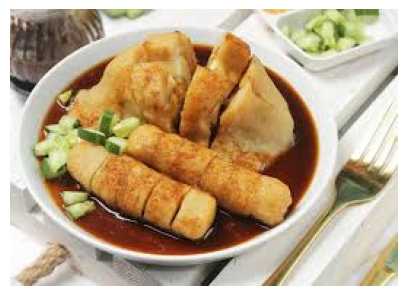

Hasil Prediksi:
------------------------------
1. pempek : 99.84%
2. mangga : 0.07%
3. ubi : 0.07%
------------------------------
Prediksi utama: pempek
Confidence: 99.84%


In [36]:
root = Tk()
root.withdraw()

image_path = filedialog.askopenfilename(
    title="Pilih gambar makanan",
    filetypes=[
        ("Image files", "*.jpg *.jpeg *.png")
    ]
)

predict_image(image_path)